# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
import spacy
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 2. Upload File

In [2]:
DATA_FILE = 'fcc_news_release_metadata_with_body_text.parquet'

df = pd.read_parquet(DATA_FILE)

# 3. Exploratory Data Analysis

## 3.1. Data Quality Checks

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3188 entries, 0 to 3187
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   page_title         3188 non-null   object        
 1   full_title         3188 non-null   object        
 2   document_type      3188 non-null   object        
 3   bureaus            3188 non-null   object        
 4   description        1577 non-null   object        
 5   webpage_url        3188 non-null   object        
 6   selected_txt_urls  3188 non-null   object        
 7   all_txt_urls       3188 non-null   object        
 8   all_txt_count      3188 non-null   int64         
 9   released_on        3188 non-null   datetime64[ns]
 10  issued_on          3188 non-null   datetime64[ns]
 11  adopted            822 non-null    datetime64[ns]
 12  filename           3188 non-null   object        
 13  body_text          3188 non-null   object        
 14  body_wor

In [4]:
qc_summary_dict = {
    'number_of_rows': df.shape[0],
    'number_of_columns': df.shape[1],
    'missing_body_text': df['body_text'].isna().sum(),
    'zero_body_word_count': (df['body_word_count'] == 0).sum(),
    'duplicate_filenames': df['filename'].duplicated().sum(),
    'min_released_on': df['released_on'].min(),
    'max_released_on': df['released_on'].max()
}

qc_summary = pd.DataFrame(
    qc_summary_dict.items(),
    columns=['metric', 'value']
)

qc_summary

,metric,value
0,number_of_rows,3188
1,number_of_columns,17
2,missing_body_text,0
3,zero_body_word_count,0
4,duplicate_filenames,0
5,min_released_on,2010-01-05 00:00:00
6,max_released_on,2026-04-30 00:00:00


In [5]:
df['extraction_method'].value_counts(dropna=False).rename('count').to_frame()

,count
extraction_method,
dateline,2207
fallback_body_like_after_front_matter,725
fallback_body_like_after_front_matter_no_city_prefix,245
fallback_body_like_after_front_matter_normal_sentence,5
fallback_after_front_matter,3
fallback_body_like_global,3


In [6]:
df['footer_method'].value_counts(dropna=False).rename('count').to_frame()

,count
footer_method,
footer_marker,3053
no_footer_marker,83
commissioner_office_footer,23
trailing_media_contact,17
office_media_footer,11
twitter,1


## 3.2. Explore Date Variables

In [7]:
df['date'] = df['released_on']
df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.to_period('Q').astype(str)
df['month'] = df['date'].dt.to_period('M').astype(str)

In [8]:
def plot_doc_trend(summary_df, x_label, y_label, tick_every=None):

    cols = summary_df.columns
    period = cols[0]
    var = cols[1]
    num_of_rows = len(summary_df)

    x_pos = range(num_of_rows)

    if tick_every == None:
        tick_every = max(1, num_of_rows // 12)
    
    plt.figure(figsize=(10, 5))
    plt.plot(x_pos, summary_df[var])
    
    plt.title(f'{y_label} by {x_label}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    tick_positions = list(range(0, num_of_rows, tick_every))
    
    plt.xticks(
        tick_positions,
        summary_df[period].astype(str).iloc[tick_positions],
        rotation=45,
        ha='right'
    )
    
    plt.tight_layout()
    plt.show()

In [9]:
word_stats_by_year = (
    df.groupby('year')['body_word_count']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

word_stats_by_year

,year,count,mean,median,min,max
0,2010,227,437.859031,336.0,39,3293
1,2011,164,502.567073,363.5,90,3067
2,2012,145,525.675862,375.0,69,3390
3,2013,138,434.826087,354.5,69,4079
4,2014,147,357.993197,337.0,85,1317
5,2015,145,397.455172,357.0,71,2228
6,2016,114,385.298246,365.5,49,896
7,2017,187,339.401070,300.0,48,2239
8,2018,195,364.589744,312.0,26,1488
9,2019,218,395.527523,350.5,91,1972


In [10]:
doc_by_year = df.groupby('year').size().rename('n_documents').reset_index()
doc_by_quarter = df.groupby('quarter').size().rename('n_documents').reset_index()
doc_by_month = df.groupby('month').size().rename('n_documents').reset_index()

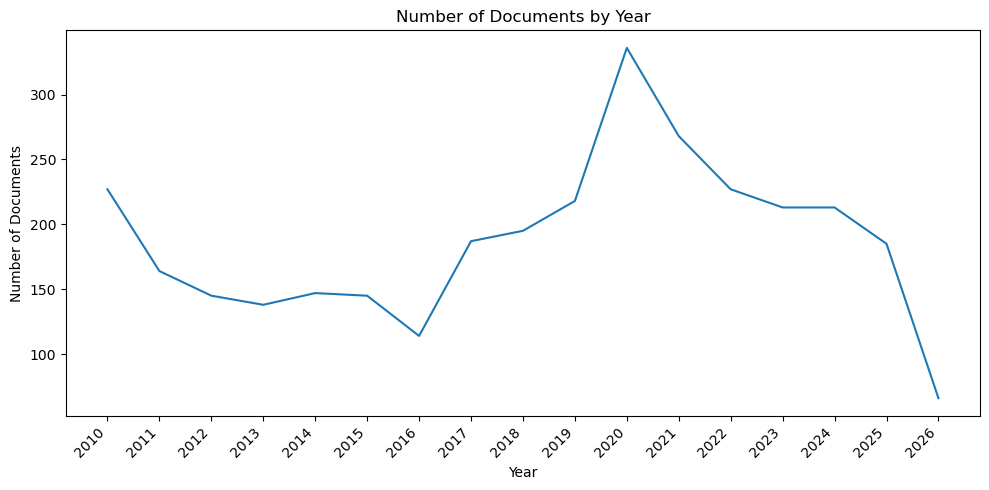

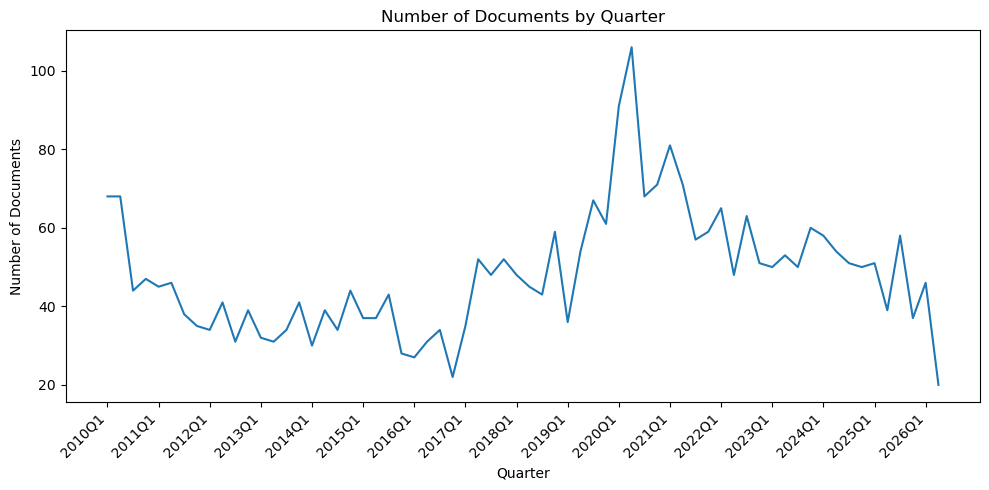

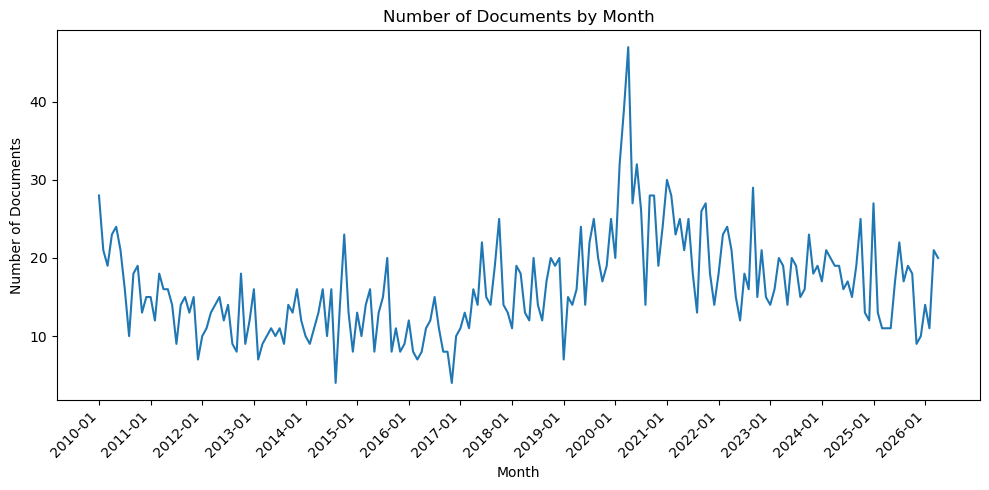

In [11]:
plot_doc_trend(doc_by_year, 'Year', 'Number of Documents', 1)
plot_doc_trend(doc_by_quarter, 'Quarter', 'Number of Documents', 4)
plot_doc_trend(doc_by_month, 'Month', 'Number of Documents', 12)

In [12]:
avg_words_by_year = df.groupby('year')['body_word_count'].mean().rename('avg_words_per_document').reset_index()
avg_words_by_quarter = df.groupby('quarter')['body_word_count'].mean().rename('avg_words_per_document').reset_index()
avg_words_by_month = df.groupby('month')['body_word_count'].mean().rename('avg_words_per_document').reset_index()

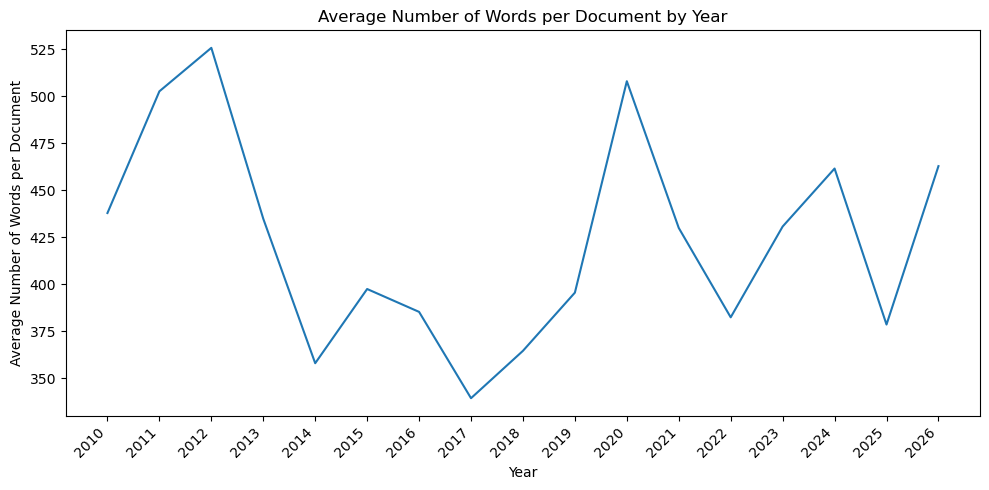

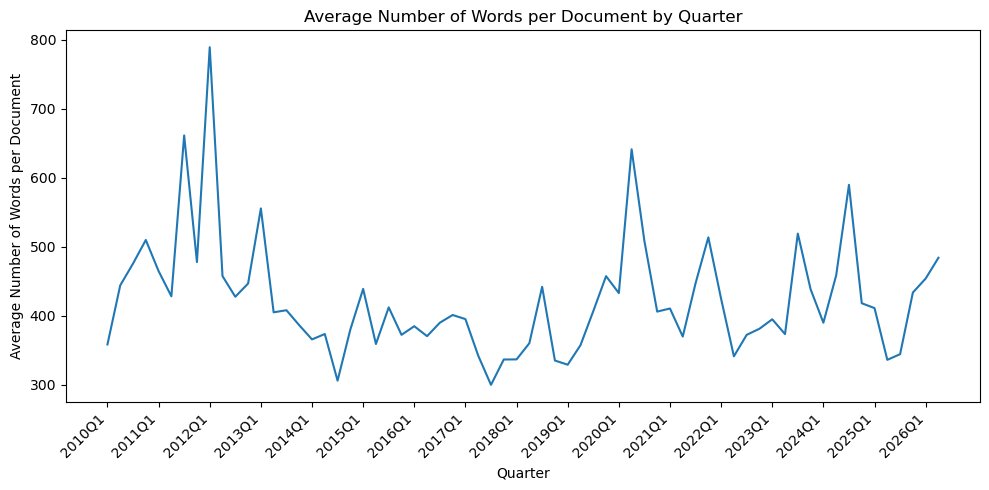

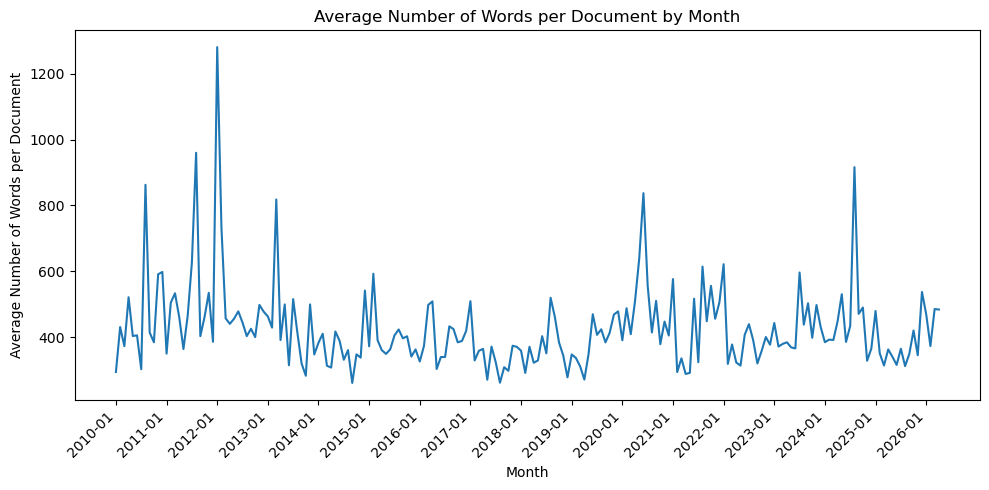

In [13]:
plot_doc_trend(avg_words_by_year, 'Year', 'Average Number of Words per Document', 1)
plot_doc_trend(avg_words_by_quarter, 'Quarter', 'Average Number of Words per Document', 4)
plot_doc_trend(avg_words_by_month, 'Month', 'Average Number of Words per Document', 12)

# 4. Text Preprocessing

In [14]:
# Load the English spaCy model.
# 1) Keep the tagger and lemmatizer for POS filtering and lemmatization.
# 2) Disable parser and NER: they are not needed for basic preprocessing 

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

text_lengths = df['body_text'].astype(str).str.len()
nlp.max_length = max(nlp.max_length, text_lengths.max() + 100)

nlp.pipe_names

['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']

In [15]:
allowed_pos = {'NOUN'}    # Alternatives: 'PROPN', 'ADJ', 'VERB'

domain_stopwords = {
    'fcc', 'federal', 'communication', 'commission',
    'commissioner', 'chairman', 'chairwoman', 'today',
    'announce', 'release', 'statement', 'order', 'rule',
    'rulemaking', 'notice', 'propose', 'proposal', 'adopt',
    'action', 'docket', 'document', 'information', 'background',
    'additional', 'separate', 'approve', 'issue', 'bureau',
    'office', 'media', 'contact', 'washington', 'dc', 'us', 'united', 'state',
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december',
    'am', 'pm'
}

In [16]:
def clean_lemma(lemma):
    '''
    Normalize a lemma returned by spaCy.
    '''
    lemma = lemma.lower().strip()
    lemma = re.sub(r'[^a-z0-9-]', '', lemma)
    return lemma

In [17]:
def preprocess_spacy_doc(doc):
    '''
    Convert one spaCy Doc object into a list of cleaned lemma tokens.
    '''
    tokens = []

    for token in doc:

        # formatting and punctuation tokens
        if token.is_space or token.is_punct or token.is_quote or token.is_bracket:
            continue

        # common or non-topic tokens
        if token.is_stop or token.like_num or token.like_url or token.like_email:
            continue

        if token.pos_ not in allowed_pos:
            continue

        lemma = clean_lemma(token.lemma_)

        if len(lemma) < 2:
            continue

        if lemma in domain_stopwords:
            continue

        tokens.append(lemma)

    return tokens

In [18]:
texts = df['body_text'].tolist()

tokens = []

for doc in tqdm(nlp.pipe(texts, batch_size=20), total=len(texts)):
    tokens.append(preprocess_spacy_doc(doc))

df['tokens'] = tokens
df['clean_text'] = df['tokens'].map(lambda tokens: ' '.join(tokens))
df['token_count'] = df['tokens'].map(len)

df[['filename', 'body_word_count', 'body_text', 'tokens', 'token_count', 'clean_text']].head()

  0%|          | 0/3188 [00:00<?, ?it/s]

,filename,body_word_count,body_text,tokens,token_count,clean_text
0,260430_FCC_Proposes_to_Amend_Audible_Crawl_Rul...,288,"Today, the Federal Communications Commission a...","[people, access, detail, emergency, viewer, us...",54,people access detail emergency viewer use stre...
1,260430_FCC_Adopts_Rules_to_Enhance_the_Integri...,342,"Today, the Federal Communications Commission a...","[integrity, program, bidding, applicant, progr...",88,integrity program bidding applicant program co...
2,260430_FCC_Targets_Covered_List_Entities_Blank...,342,"Today, the Federal Communications Commission v...","[proceeding, entity, agency, authorization, te...",67,proceeding entity agency authorization telecom...
3,260430_FCC_Targets_Device_Test_Labs_in_Nations...,406,"Today, the Federal Communications Commission v...","[recognition, device, test, lab, certification...",99,recognition device test lab certification body...
4,260430_FCC_Proposes_Strengthening_Know-Your-Cu...,298,In an effort to stop illegal calls before they...,"[effort, call, people, item, voice, service, p...",64,effort call people item voice service provider...


In [19]:
preprocessing_summary_dict = {
    'number_of_documents': int(df.shape[0]),
    'min_token_count': int(df['token_count'].min()),
    'mean_token_count': int(round(df['token_count'].mean())),
    'median_token_count': int(df['token_count'].median()),
    'max_token_count': int(df['token_count'].max())
}

preprocessing_summary = pd.DataFrame(
    preprocessing_summary_dict.items(),
    columns=['metric', 'value']
)

preprocessing_summary

,metric,value
0,number_of_documents,3188
1,min_token_count,2
2,mean_token_count,94
3,median_token_count,75
4,max_token_count,1912


# 5. Term Frequency

## 5.1. Raw Term Frequency

### 5.1.1. Overall

In [20]:
count_vectorizer = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 1),
    max_df=0.8,
    min_df=5
)

X_counts = count_vectorizer.fit_transform(df['clean_text'].fillna(''))

terms = count_vectorizer.get_feature_names_out()

In [21]:
term_counts = np.asarray(X_counts.sum(axis=0)).ravel()

term_freq = pd.DataFrame({
    'term': terms,
    'count': term_counts.astype(int)
})

term_freq = term_freq.sort_values('count', ascending=False).reset_index(drop=True)

term_freq.head(30)

,term,count
0,service,8375
1,consumer,4438
2,provider,4094
3,broadband,3852
4,program,2902
5,network,2794
6,access,2616
7,spectrum,2276
8,year,2255
9,internet,1909


### 5.1.2. By Year, Quarter or Month

In [22]:
def get_term_frequency_by_period(df, X, terms, period_col, top_n=5):
    data = df[[period_col]].reset_index(drop=True)

    rows = []

    for period, period_df in data.groupby(period_col, sort=True):
        idx = period_df.index.to_numpy()

        counts = np.asarray(X[idx].sum(axis=0)).ravel()
        top_idx = counts.argsort()[::-1][:top_n]

        period_result = pd.DataFrame({
            period_col: period,
            'term': terms[top_idx],
            'count': counts[top_idx].astype(int)
        })

        period_result = period_result[period_result['count'] > 0]

        rows.append(period_result)

    return pd.concat(rows, ignore_index=True)

In [23]:
term_freq_by_year = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='year',
    top_n=5
)

term_freq_by_quarter = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='quarter',
    top_n=5
)

term_freq_by_month = get_term_frequency_by_period(
    df=df,
    X=X_counts,
    terms=terms,
    period_col='month',
    top_n=5
)

In [24]:
term_freq_by_year.head(20)

,year,term,count
0,2010,service,646
1,2010,broadband,485
2,2010,consumer,350
3,2010,complaint,291
4,2010,internet,274
5,2011,service,539
6,2011,broadband,321
7,2011,consumer,296
8,2011,program,195
9,2011,technology,163


In [25]:
term_freq_by_quarter.head(20)

,quarter,term,count
0,2010Q1,service,123
1,2010Q1,broadband,121
2,2010Q1,consumer,72
3,2010Q1,internet,65
4,2010Q1,speed,56
5,2010Q2,service,210
6,2010Q2,broadband,168
7,2010Q2,consumer,111
8,2010Q2,complaint,106
9,2010Q2,network,101


In [26]:
term_freq_by_month.head(20)

,month,term,count
0,2010-01,consumer,45
1,2010-01,service,25
2,2010-01,system,25
3,2010-01,radio,25
4,2010-01,request,23
5,2010-02,broadband,52
6,2010-02,service,51
7,2010-02,speed,41
8,2010-02,network,39
9,2010-02,internet,30


## 5.2. N-Gram Frequency

### 5.2.1. Overall

In [27]:
def get_ngram_frequency(df, text_col, ngram_range, max_df=1.0, min_df=1):
    ngram_vectorizer = CountVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        ngram_range=ngram_range,
        max_df=max_df,
        min_df=min_df
    )

    X_ngrams = ngram_vectorizer.fit_transform(df[text_col].fillna(''))

    ngram_terms = ngram_vectorizer.get_feature_names_out()

    ngram_counts = np.asarray(X_ngrams.sum(axis=0)).ravel()

    ngram_freq = pd.DataFrame({
        'ngram': ngram_terms,
        'count': ngram_counts.astype(int)
    })

    ngram_freq = (
        ngram_freq
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )

    return ngram_freq, X_ngrams, ngram_terms

In [28]:
bigram_freq, X_bigrams, bigram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 2),
    max_df=0.8,
    min_df=5
)

bigram_freq.head(20)

,ngram,count
0,service provider,1003
1,health care,705
2,broadband service,567
3,school library,549
4,ghz band,511
5,voice service,423
6,care provider,330
7,internet service,306
8,internet access,283
9,access service,262


In [29]:
trigram_freq, X_trigrams, trigram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(3, 3),
    max_df=0.8,
    min_df=5
)

trigram_freq.head(20)

,ngram,count
0,health care provider,316
1,voice service provider,273
2,waste fraud abuse,120
3,page cover sheet,104
4,draft text item,104
5,cover sheet draft,103
6,sheet draft item,103
7,draft item material,102
8,item material page,94
9,school library consortium,94


In [30]:
ngram_freq, X_ngrams, ngram_terms = get_ngram_frequency(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 3),
    max_df=0.8,
    min_df=5
)

ngram_freq.head(20)

,ngram,count
0,service provider,1003
1,health care,705
2,broadband service,567
3,school library,549
4,ghz band,511
5,voice service,423
6,care provider,330
7,health care provider,316
8,internet service,306
9,internet access,283


### 5.2.2. By Year, Quarter or Month

In [31]:
ngram_freq_by_year = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='year',
    top_n=5
)

ngram_freq_by_quarter = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='quarter',
    top_n=5
)

ngram_freq_by_month = get_term_frequency_by_period(
    df=df,
    X=X_ngrams,
    terms=ngram_terms,
    period_col='month',
    top_n=5
)

In [32]:
ngram_freq_by_year.head(20)

,year,term,count
0,2010,complaint inquiry,125
1,2010,people disability,55
2,2010,health care,54
3,2010,broadband network,53
4,2010,broadband service,52
5,2011,service provider,53
6,2011,broadband service,42
7,2011,school library,29
8,2011,telephone company,26
9,2011,inquiry complaint,24


## 5.3. TF-IDF Scores

### 5.3.1. Overall (1): Raw Term

In [33]:
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    ngram_range=(1, 1),
    max_df=0.8,
    min_df=5
)

X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'].fillna(''))

tfidf_terms = tfidf_vectorizer.get_feature_names_out()

In [34]:
tfidf_mean = np.asarray(X_tfidf.mean(axis=0)).ravel()
document_frequency = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()

tfidf_scores = pd.DataFrame({
    'term': tfidf_terms,
    'tfidf_mean': tfidf_mean,
    'document_frequency': document_frequency
})

tfidf_scores = (
    tfidf_scores
    .sort_values('tfidf_mean', ascending=False)
    .reset_index(drop=True)
)

tfidf_scores.head(20)

,term,tfidf_mean,document_frequency
0,service,0.057638,2056
1,consumer,0.042520,1259
2,broadband,0.041515,1084
3,provider,0.037210,1168
4,program,0.034899,877
5,spectrum,0.033258,583
6,network,0.029367,975
7,band,0.025555,387
8,access,0.025544,1110
9,year,0.024085,1232


### 5.3.2. Overall (2): N-Gram

In [35]:
def get_tfidf_scores(df, text_col, ngram_range, max_df=1.0, min_df=1):
    tfidf_vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        ngram_range=ngram_range,
        max_df=max_df,
        min_df=min_df
    )

    X_tfidf = tfidf_vectorizer.fit_transform(df[text_col].fillna(''))

    tfidf_terms = tfidf_vectorizer.get_feature_names_out()

    tfidf_mean = np.asarray(X_tfidf.mean(axis=0)).ravel()
    document_frequency = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()

    tfidf_scores = pd.DataFrame({
        'term': tfidf_terms,
        'tfidf_mean': tfidf_mean,
        'document_frequency': document_frequency
    })

    tfidf_scores = (
        tfidf_scores
        .sort_values('tfidf_mean', ascending=False)
        .reset_index(drop=True)
    )

    return tfidf_scores, X_tfidf, tfidf_terms

In [36]:
tfidf_bigram_scores, X_tfidf_bigram, tfidf_bigram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 2),
    max_df=0.8,
    min_df=5
)

tfidf_bigram_scores.head(20)

,term,tfidf_mean,document_frequency
0,service provider,0.016779,521
1,school library,0.012877,167
2,ghz band,0.012787,185
3,broadband service,0.011778,368
4,health care,0.011637,205
5,voice service,0.008961,206
6,item agenda,0.007910,197
7,internet service,0.007494,207
8,people disability,0.006983,145
9,broadcast station,0.006599,134


In [37]:
tfidf_trigram_scores, X_tfidf_trigram, tfidf_trigram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(3, 3),
    max_df=0.8,
    min_df=5
)

tfidf_trigram_scores.head(20)

,term,tfidf_mean,document_frequency
0,voice service provider,0.012133,109
1,health care provider,0.011200,93
2,waste fraud abuse,0.009956,89
3,item agenda meeting,0.009404,62
4,internet service provider,0.006186,68
5,hearing speech disability,0.005962,46
6,internet access service,0.005579,60
7,spectrum ghz band,0.004920,56
8,request description accommodation,0.004913,67
9,power tv power,0.004797,38


In [38]:
tfidf_ngram_scores, X_tfidf_ngram, tfidf_ngram_terms = get_tfidf_scores(
    df=df,
    text_col='clean_text',
    ngram_range=(2, 3),
    max_df=0.8,
    min_df=5
)

tfidf_ngram_scores.head(20)

,term,tfidf_mean,document_frequency
0,service provider,0.015091,521
1,ghz band,0.011451,185
2,school library,0.010836,167
3,broadband service,0.010737,368
4,health care,0.010446,205
5,voice service,0.007871,206
6,internet service,0.006902,207
7,item agenda,0.006750,197
8,people disability,0.006262,145
9,internet access,0.006005,187


### 5.3.3. By Year, Quarter or Month

In [39]:
def get_tfidf_mean_by_period(df, X, terms, period_col, top_n=5):
    data = df[[period_col]].reset_index(drop=True)

    rows = []

    for period, period_df in data.groupby(period_col, sort=True):
        idx = period_df.index.to_numpy()

        tfidf_mean = np.asarray(X[idx].mean(axis=0)).ravel()
        document_frequency = np.asarray((X[idx] > 0).sum(axis=0)).ravel()

        top_idx = tfidf_mean.argsort()[::-1][:top_n]

        period_result = pd.DataFrame({
            period_col: period,
            'term': terms[top_idx],
            'tfidf_mean': tfidf_mean[top_idx],
            'document_frequency': document_frequency[top_idx]
        })

        period_result = period_result[period_result['tfidf_mean'] > 0]

        rows.append(period_result)

    return pd.concat(rows, ignore_index=True)

In [40]:
tfidf_by_year = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='year',
    top_n=5
)

tfidf_by_quarter = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='quarter',
    top_n=5
)

tfidf_by_month = get_tfidf_mean_by_period(
    df=df,
    X=X_tfidf_ngram,
    terms=tfidf_ngram_terms,
    period_col='month',
    top_n=5
)

In [41]:
tfidf_by_year.head(20)

,year,term,tfidf_mean,document_frequency
0,2010,people disability,0.026834,37
1,2010,mail voice,0.016861,28
2,2010,description accommodation,0.016623,29
3,2010,disability request,0.016145,29
4,2010,disability request description,0.015937,27
5,2011,broadband service,0.016976,28
6,2011,item agenda meeting,0.015788,12
7,2011,agenda meeting,0.015405,12
8,2011,job creation,0.012628,13
9,2011,item agenda,0.012117,12


In [42]:
tfidf_by_quarter.head(20)

,quarter,term,tfidf_mean,document_frequency
0,2010Q1,people disability,0.030179,16
1,2010Q1,disability request description,0.023918,13
2,2010Q1,mail voice,0.023918,13
3,2010Q1,request description accommodation,0.023698,13
4,2010Q1,request description,0.023698,13
5,2010Q2,people disability,0.029009,13
6,2010Q2,broadband network,0.026710,9
7,2010Q2,safety broadband,0.023525,5
8,2010Q2,mail voice,0.021851,10
9,2010Q2,minute request mail,0.019102,8


In [43]:
tfidf_by_month.head(20)

,month,term,tfidf_mean,document_frequency
0,2010-01,relief effort,0.043922,3
1,2010-01,court decision,0.035714,1
2,2010-01,consumer experience,0.031695,2
3,2010-01,mail voice,0.031474,7
4,2010-01,disability request description,0.031474,7
5,2010-02,barrier adoption,0.047238,3
6,2010-02,non adopter,0.040803,1
7,2010-02,emergency response,0.039321,2
8,2010-02,penetration rate,0.038182,1
9,2010-02,safety broadband,0.034809,1
